# COMPAS Notebook 1 — EDA and Preprocessing
## Bias Analysis in ML Models using Explainable AI

**Dataset:** COMPAS Recidivism (ProPublica, 2016)  
**Target:** `two_year_recid` — did this person reoffend within two years? (1 = yes, 0 = no)  
**Primary harm metric:** FPR — a false positive means a person who did NOT reoffend was wrongly flagged as high risk  
**Sensitive attributes:** `race`, `sex`, `age_cat`  

---

### Why COMPAS is structurally different from Adult Census

Adult Census asks: does this person earn >50K? The harm of a false negative (missing a high earner) falls on the individual — they are wrongly denied opportunity.

COMPAS asks: will this person reoffend? The harm of a **false positive** is more severe in this context — a person who would NOT have reoffended is labelled high-risk, which can influence bail, sentencing, and parole decisions. This is the civil liberties harm ProPublica documented in 2016: Black defendants were nearly twice as likely to be falsely flagged as high risk compared to White defendants.

**This means FPR is foregrounded throughout this analysis, not FNR.**

---

### Proxy features to watch

In Adult Census, `relationship` and `marital-status` were proxies for sex. In COMPAS, the analogous proxies for race are:
- `priors_count` — number of prior offenses. Correlates with race due to over-policing of Black communities.
- `age` / `age_cat` — younger defendants are more likely to be Black in this dataset due to demographic patterns in the justice system.
- `juv_fel_count`, `juv_misd_count` — juvenile offense history. Same over-policing concern.

We do not remove these features — we document their role and flag them in XAI analysis.

---
## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import requests
import io
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

RANDOM_STATE = 42
print('Imports complete.')

Imports complete.


---
## 1. Load Data from ProPublica GitHub

In [2]:
URL = 'https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv'

response = requests.get(URL)
response.raise_for_status()
df_raw = pd.read_csv(io.StringIO(response.text))

print(f'Raw shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')

Raw shape: (7214, 53)
Columns: ['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1', 'start', 'end', 'event', 'two_year_recid']


---
## 2. Apply ProPublica Filtering Criteria

ProPublica applied specific filters in their original analysis to exclude invalid or unreliable records. We replicate these exactly so our results are comparable to theirs and to the academic literature that uses this dataset.

In [3]:
# ProPublica filtering criteria (from their methodology)
df = df_raw.copy()

# 1. Keep only rows where days_b_screening_arrest is within 30 days
#    (screening must be close in time to arrest to be valid)
df = df[df['days_b_screening_arrest'].between(-30, 30)]

# 2. Remove cases where is_recid == -1 (data error)
df = df[df['is_recid'] != -1]

# 3. Keep only c_charge_degree == 'F' or 'M' (Felony or Misdemeanor, drop others)
df = df[df['c_charge_degree'].isin(['F', 'M'])]

# 4. Remove score_text == 'N/A'
df = df[df['score_text'] != 'N/A']

# 5. Keep only African-American and Caucasian for race
#    (ProPublica focused on these two groups for statistical power)
#    We keep all groups but note this for reference
print(f'After filtering: {df.shape[0]} rows')
print(f'Race distribution after filtering:')
print(df['race'].value_counts())
print(f'\nTarget distribution (two_year_recid):')
print(df['two_year_recid'].value_counts(normalize=True).round(3))

After filtering: 6172 rows
Race distribution after filtering:
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64

Target distribution (two_year_recid):
two_year_recid
0    0.545
1    0.455
Name: proportion, dtype: float64


---
## 3. Feature Selection

COMPAS has many columns — case IDs, dates, free text fields, and redundant score columns. We select only the columns that are:
1. Available at the time of prediction (no data leakage)
2. Meaningful features (not IDs or administrative fields)
3. Not direct transformations of the target

In [4]:
# Features available at prediction time
FEATURE_COLS = [
    'age',
    'age_cat',          # Less than 25 / 25 - 45 / Greater than 45
    'sex',
    'race',
    'juv_fel_count',    # Juvenile felony count
    'juv_misd_count',   # Juvenile misdemeanor count
    'juv_other_count',  # Other juvenile charges
    'priors_count',     # Number of prior charges
    'c_charge_degree',  # Current charge: Felony (F) or Misdemeanor (M)
]

TARGET_COL = 'two_year_recid'

# NOTE: We intentionally EXCLUDE:
# - decile_score, score_text: these ARE the COMPAS score, not input features
#   Including them would be predicting the score, not recidivism
# - id, name, first, last, dob: identifiers
# - compas_screening_date, c_jail_in, c_jail_out: dates
# - v_decile_score: violent score (different prediction task)
print('Excluded columns with reason:')
print('  decile_score, score_text — COMPAS output, would leak the label')
print('  All ID and date columns — identifiers, no predictive value')
print(f'\nSelected {len(FEATURE_COLS)} feature columns + 1 target')

df_model = df[FEATURE_COLS + [TARGET_COL]].copy()
print(f'Model dataset shape: {df_model.shape}')
print(f'\nMissing values per column:')
print(df_model.isnull().sum())

Excluded columns with reason:
  decile_score, score_text — COMPAS output, would leak the label
  All ID and date columns — identifiers, no predictive value

Selected 9 feature columns + 1 target
Model dataset shape: (6172, 10)

Missing values per column:
age                0
age_cat            0
sex                0
race               0
juv_fel_count      0
juv_misd_count     0
juv_other_count    0
priors_count       0
c_charge_degree    0
two_year_recid     0
dtype: int64


---
## 4. EDA

### 4.1 Target Distribution

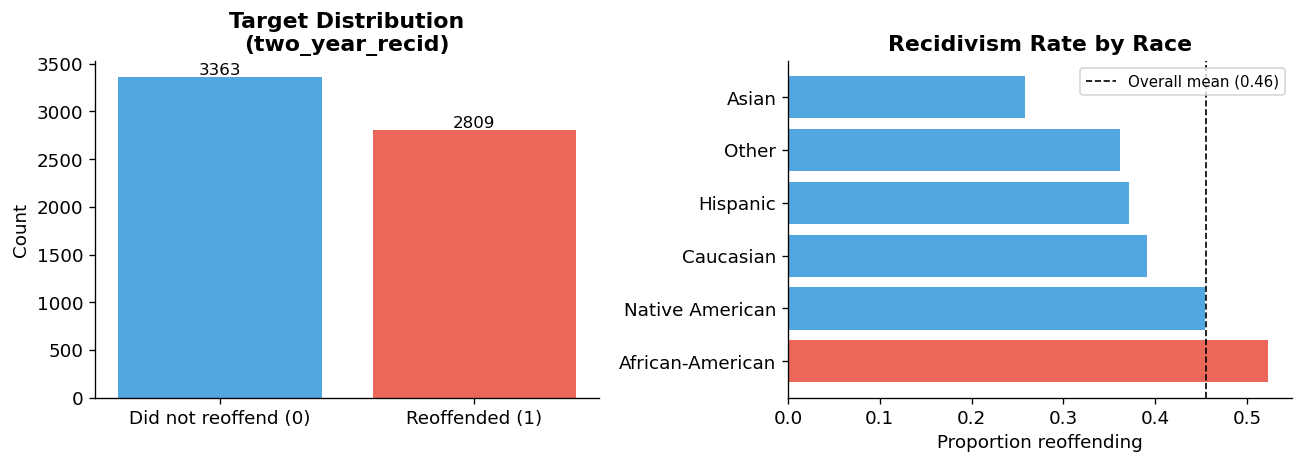

Overall recidivism rate: 0.455


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Overall target
counts = df_model[TARGET_COL].value_counts()
axes[0].bar(['Did not reoffend (0)', 'Reoffended (1)'], counts.values,
            color=['#3498db', '#e74c3c'], alpha=0.85)
axes[0].set_title('Target Distribution\n(two_year_recid)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=10)

# Recidivism rate by race
recid_by_race = df_model.groupby('race')[TARGET_COL].mean().sort_values(ascending=False)
colors = ['#e74c3c' if r in ['African-American'] else '#3498db' for r in recid_by_race.index]
axes[1].barh(recid_by_race.index, recid_by_race.values, color=colors, alpha=0.85)
axes[1].axvline(df_model[TARGET_COL].mean(), color='black', linestyle='--',
                linewidth=1, label=f'Overall mean ({df_model[TARGET_COL].mean():.2f})')
axes[1].set_title('Recidivism Rate by Race', fontweight='bold')
axes[1].set_xlabel('Proportion reoffending')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('compas_target_distribution.png', bbox_inches='tight')
plt.show()
print(f'Overall recidivism rate: {df_model[TARGET_COL].mean():.3f}')

While asian defendants show the lowest recidivism rate, the sample size (n=31) is too small for significant interference.


### 4.2 Sensitive Attribute Distributions

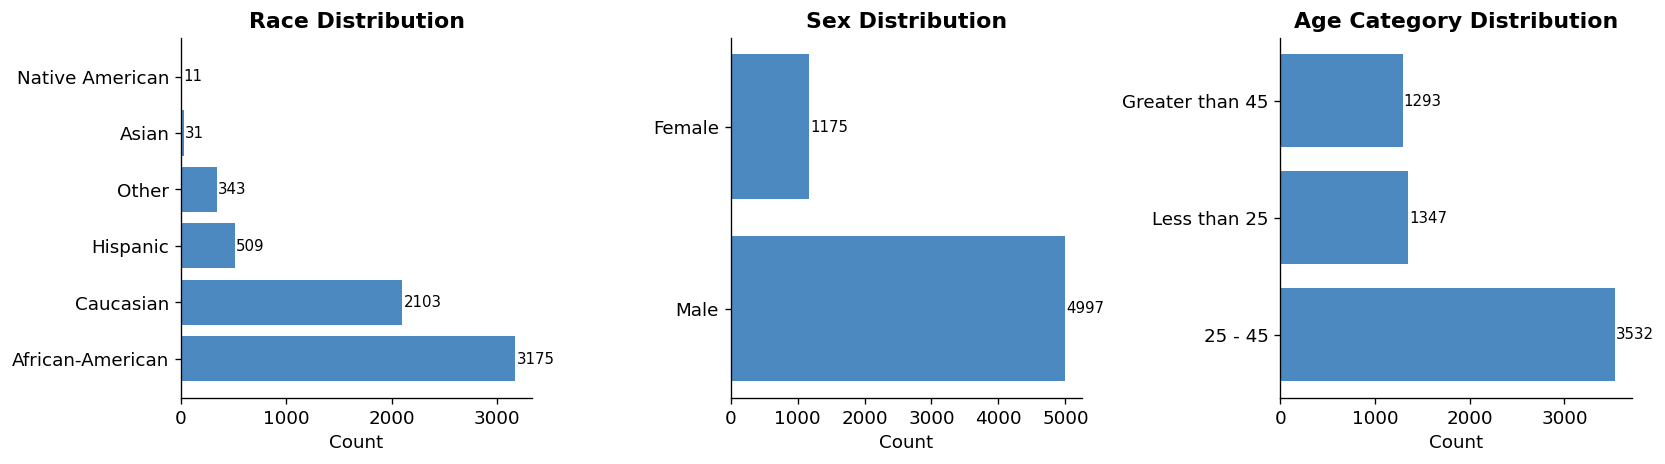


Note: Group sizes matter for statistical reliability.
Groups below n=30 in the test set will be excluded from group-wise analysis.

Race counts:
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(axes,
                           ['race', 'sex', 'age_cat'],
                           ['Race Distribution', 'Sex Distribution', 'Age Category Distribution']):
    counts = df_model[col].value_counts()
    ax.barh(counts.index, counts.values, color='#2E75B6', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(v + 10, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('compas_sensitive_distributions.png', bbox_inches='tight')
plt.show()

print('\nNote: Group sizes matter for statistical reliability.')
print('Groups below n=30 in the test set will be excluded from group-wise analysis.')
print(f'\nRace counts:')
print(df_model['race'].value_counts())

### 4.3 Recidivism Rate by Sensitive Attribute

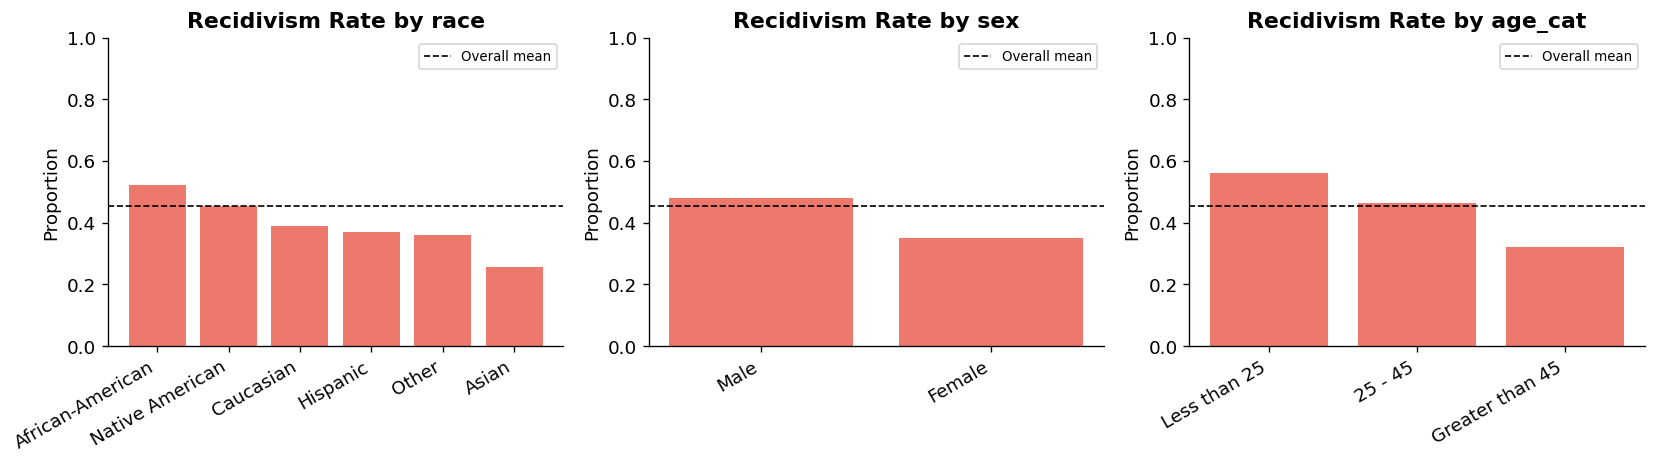

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['race', 'sex', 'age_cat']):
    rates = df_model.groupby(col)[TARGET_COL].mean().sort_values(ascending=False)
    ax.bar(rates.index, rates.values, color='#e74c3c', alpha=0.75)
    ax.axhline(df_model[TARGET_COL].mean(), color='black', linestyle='--',
               linewidth=1, label='Overall mean')
    ax.set_title(f'Recidivism Rate by {col}', fontweight='bold')
    ax.set_ylabel('Proportion')
    ax.set_xticklabels(rates.index, rotation=30, ha='right')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('compas_recidivism_by_group.png', bbox_inches='tight')
plt.show()

### 4.4 Key Numeric Features

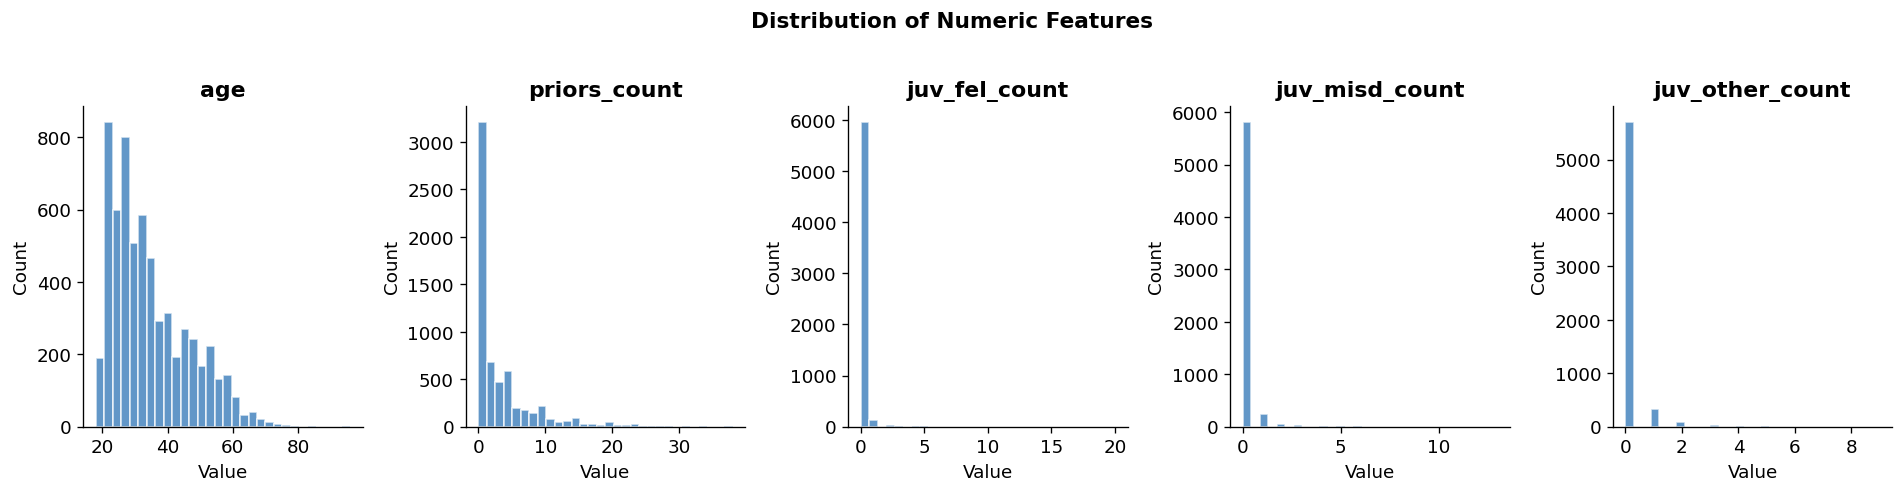

           age  priors_count  juv_fel_count  juv_misd_count  juv_other_count
count  6172.00       6172.00        6172.00         6172.00          6172.00
mean     34.53          3.25           0.06            0.09             0.11
std      11.73          4.74           0.46            0.50             0.47
min      18.00          0.00           0.00            0.00             0.00
25%      25.00          0.00           0.00            0.00             0.00
50%      31.00          1.00           0.00            0.00             0.00
75%      42.00          4.00           0.00            0.00             0.00
max      96.00         38.00          20.00           13.00             9.00


In [8]:
numeric_features = ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count']

fig, axes = plt.subplots(1, len(numeric_features), figsize=(16, 4))

for ax, feat in zip(axes, numeric_features):
    ax.hist(df_model[feat], bins=30, color='#2E75B6', alpha=0.75, edgecolor='white')
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Distribution of Numeric Features', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('compas_numeric_distributions.png', bbox_inches='tight')
plt.show()

print(df_model[numeric_features].describe().round(2))

### 4.5 priors_count by Race — The Core ProPublica Finding

`priors_count` is the single most predictive feature for recidivism in most models trained on this data. But prior charges are not race-neutral — Black individuals are more likely to have higher prior counts due to documented over-policing patterns. If the model relies heavily on `priors_count`, it is using a feature that encodes historical racial bias.

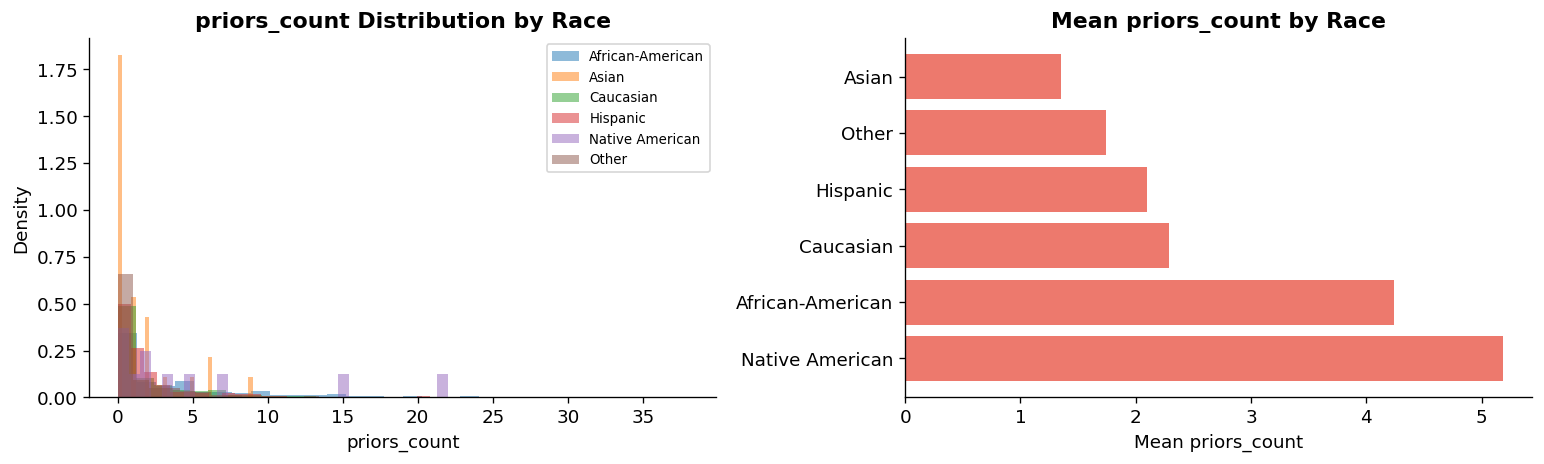

Mean priors_count by race:
race
Native American     5.18
African-American    4.24
Caucasian           2.29
Hispanic            2.10
Other               1.75
Asian               1.35
Name: priors_count, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# priors_count distribution by race
for race_val, grp in df_model.groupby('race'):
    axes[0].hist(grp['priors_count'], bins=30, alpha=0.5, label=race_val, density=True)
axes[0].set_title('priors_count Distribution by Race', fontweight='bold')
axes[0].set_xlabel('priors_count')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Mean priors_count per race
mean_priors = df_model.groupby('race')['priors_count'].mean().sort_values(ascending=False)
axes[1].barh(mean_priors.index, mean_priors.values, color='#e74c3c', alpha=0.75)
axes[1].set_title('Mean priors_count by Race', fontweight='bold')
axes[1].set_xlabel('Mean priors_count')

plt.tight_layout()
plt.savefig('compas_priors_by_race.png', bbox_inches='tight')
plt.show()

print('Mean priors_count by race:')
print(mean_priors.round(2))

### 4.6 Correlation Heatmap

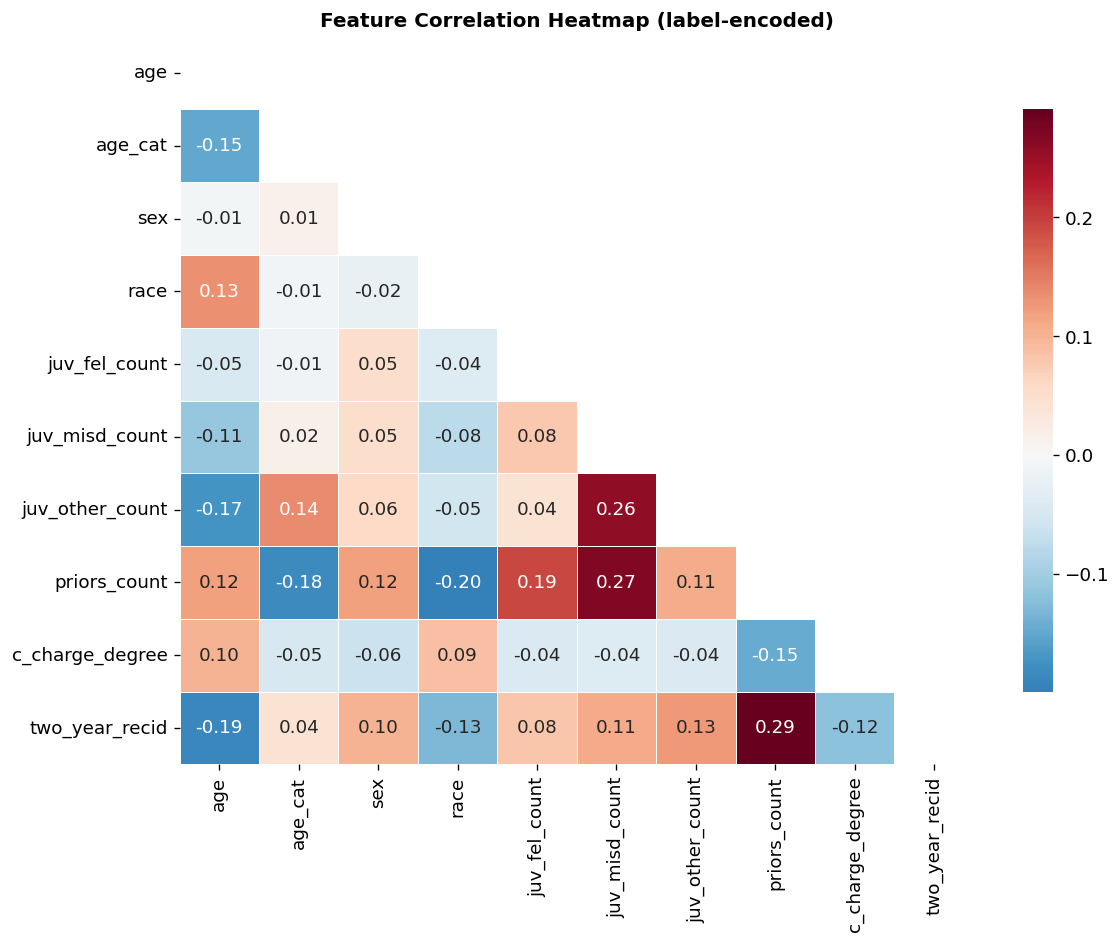

Features correlated with race (|r| > 0.1):
priors_count       0.199
age                0.133
two_year_recid     0.129
c_charge_degree    0.087
juv_misd_count     0.077
juv_other_count    0.055
juv_fel_count      0.040
sex                0.022
age_cat            0.010
Name: race, dtype: float64


In [10]:
# Encode categoricals temporarily for correlation
df_corr = df_model.copy()
for col in df_corr.select_dtypes('object').columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap (label-encoded)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('compas_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Flag features with correlation > 0.3 with race
print('Features correlated with race (|r| > 0.1):')
print(corr['race'].abs().sort_values(ascending=False)[1:].round(3))

The correlation heatmap reveals that priors_count is the strongest predictor of the target variable (r=0.29). However, it also shows a significant correlation with race (r=0.20). This suggests that priors_count acts as a 'proxy feature' for race, explaining why the COMPAS algorithm—and models trained on this data—exhibit racial disparity in their risk assessments

---
## 5. Preprocessing

In [11]:
# Save original sensitive attribute values BEFORE encoding
# We need these for group-wise analysis later
df_processed = df_model.copy()

# Record sensitive columns in original form
sensitive_raw = df_processed[['race', 'sex', 'age_cat']].copy()

# Label encode all categorical columns
label_encoders = {}
categorical_cols = df_processed.select_dtypes(include='object').columns.tolist()
categorical_cols = [c for c in categorical_cols if c != TARGET_COL]

print('Encoding categorical columns:')
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'  {col}: {mapping}')

print(f'\nFinal processed shape: {df_processed.shape}')
print(f'Dtypes after encoding:')
print(df_processed.dtypes)

Encoding categorical columns:
  age_cat: {'25 - 45': np.int64(0), 'Greater than 45': np.int64(1), 'Less than 25': np.int64(2)}
  sex: {'Female': np.int64(0), 'Male': np.int64(1)}
  race: {'African-American': np.int64(0), 'Asian': np.int64(1), 'Caucasian': np.int64(2), 'Hispanic': np.int64(3), 'Native American': np.int64(4), 'Other': np.int64(5)}
  c_charge_degree: {'F': np.int64(0), 'M': np.int64(1)}

Final processed shape: (6172, 10)
Dtypes after encoding:
age                int64
age_cat            int64
sex                int64
race               int64
juv_fel_count      int64
juv_misd_count     int64
juv_other_count    int64
priors_count       int64
c_charge_degree    int64
two_year_recid     int64
dtype: object


---
## 6. Train/Test Split

In [13]:
X = df_processed.drop(columns=[TARGET_COL])
y = df_processed[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y  # preserve class balance in both splits
)

# Align sensitive attributes to test set
sensitive_test = sensitive_raw.loc[X_test.index].reset_index(drop=True)
sensitive_test['sex_race'] = sensitive_test['sex'] + '_' + sensitive_test['race']
sensitive_test['sex_age']  = sensitive_test['sex'] + '_' + sensitive_test['age_cat']

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f'Train size: {X_train.shape[0]}')
print(f'Test size:  {X_test.shape[0]}')
print(f'\nTrain target distribution:')
print(y_train.value_counts(normalize=True).round(3))
print(f'\nTest target distribution:')
print(y_test.value_counts(normalize=True).round(3))

Train size: 4937
Test size:  1235

Train target distribution:
two_year_recid
0    0.545
1    0.455
Name: proportion, dtype: float64

Test target distribution:
two_year_recid
0    0.545
1    0.455
Name: proportion, dtype: float64


---
## 7. Dataset Bias Analysis

Before training any model, we document representation imbalances in the training data. These imbalances are what cause the model to learn biased patterns.

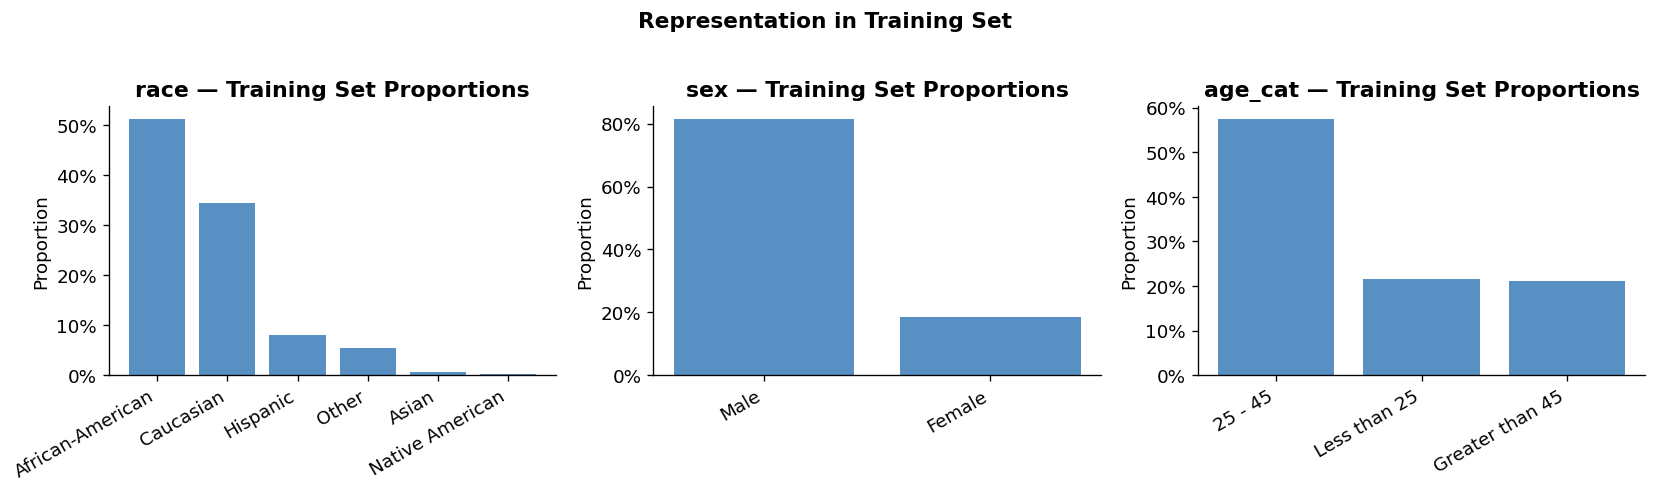

In [14]:
# Add race back to training set for analysis
train_sensitive = sensitive_raw.iloc[X_train.index].reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['race', 'sex', 'age_cat']):
    counts = train_sensitive[col].value_counts()
    ax.bar(counts.index, counts.values / counts.sum(), color='#2E75B6', alpha=0.8)
    ax.set_title(f'{col} — Training Set Proportions', fontweight='bold')
    ax.set_ylabel('Proportion')
    ax.set_xticklabels(counts.index, rotation=30, ha='right')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.suptitle('Representation in Training Set', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('compas_training_representation.png', bbox_inches='tight')
plt.show()

In [ ]:
# Recidivism rate by race in training set
train_with_target = train_sensitive.copy()
train_with_target['two_year_recid'] = y_train.values

print('Recidivism rate by race in TRAINING set:')
print(train_with_target.groupby('race')['two_year_recid'].agg(['mean', 'count']).round(3))

print('\nRecidivism rate by sex in TRAINING set:')
print(train_with_target.groupby('sex')['two_year_recid'].agg(['mean', 'count']).round(3))

print('\nRecidivism rate by age_cat in TRAINING set:')
print(train_with_target.groupby('age_cat')['two_year_recid'].agg(['mean', 'count']).round(3))

The training set exhibits significant demographic skew, particularly in sex (80% male) and race (majority African-American). Consequently, the model's 'learned' patterns will be heavily optimized for these majority groups, potentially leading to higher error rates or lower reliability for female and minority ethnic defendants due to data sparsity

---
## 8. Save Artefacts

In [15]:
import joblib

X_train.to_csv('compas_X_train.csv', index=False)
X_test.to_csv('compas_X_test.csv', index=False)
y_train.to_csv('compas_y_train.csv', index=False)
y_test.to_csv('compas_y_test.csv', index=False)
sensitive_test.to_csv('compas_sensitive_test.csv', index=False)

# Save label encoders for decoding later
joblib.dump(label_encoders, 'compas_label_encoders.pkl')

print('Saved:')
print('  compas_X_train.csv')
print('  compas_X_test.csv')
print('  compas_y_train.csv')
print('  compas_y_test.csv')
print('  compas_sensitive_test.csv')
print('  compas_label_encoders.pkl')

Saved:
  compas_X_train.csv
  compas_X_test.csv
  compas_y_train.csv
  compas_y_test.csv
  compas_sensitive_test.csv
  compas_label_encoders.pkl


---
## 9. EDA Summary

Fill in after running.

**Dataset size after ProPublica filtering:** 6,172 rows

**Overall recidivism rate:** 0.455(balanced) note whether this is balanced or imbalanced

**Racial composition:** African-American [51.4]%, Caucasian [34.1]%, other groups smaller

**Key dataset bias observations:**
- African-American defendants have a higher mean priors_count ([4.24]) vs Caucasian ([2.29])
- Recidivism rate varies across racial groups: African-American [52.3], Caucasian [39.1]
- priors_count correlates with race (r = [0.2])
- These observations mean any model trained on this data that relies on priors_count will partially reflect historical over-policing patterns

**Features flagged as potential proxies for race:**
- `priors_count` — correlates with race, will check SHAP in Notebook 2
- `juv_fel_count`, `juv_misd_count` — juvenile history, same concern
- `age_cat` — demographic correlation with race in this dataset